# MNIST Handwritten Digit Classification using a Multi-Layer Perceptron (MLP)

## Overview

This notebook demonstrates the implementation of a **Multi-Layer Perceptron (MLP)** using **TensorFlow** and **Keras** to classify handwritten digits from the **MNIST** dataset. It covers the complete deep learning workflow, including data preprocessing, model creation, training, evaluation, performance visualization, and prediction.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Observations

- `load_data()` returns two tuples.
- First tuple → Training data
    - `x_train` : Images
    - `y_train` : Labels
- Second tuple → Testing data
    - `x_test` : Images
    - `y_test` : Labels

In [ ]:
print(type(x_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Inspect the dataset to understand its dimensions before preprocessing.

In [ ]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


## Observations

- Training images shape: `(60000, 28, 28)`
- Training labels shape: `(60000,)`
- Testing images shape: `(10000, 28, 28)`
- Testing labels shape: `(10000,)`

Interpretation:
- 60,000 training images
- Each image is 28 × 28 pixels
- Each image has one corresponding label

Visualize one image from the dataset and verify its corresponding label.

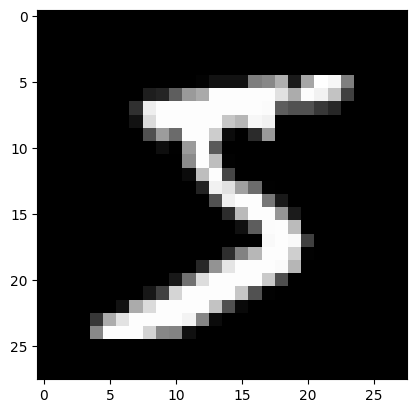

Label: 5


In [ ]:
plt.imshow(x_train[0], cmap="gray")
plt.show()

print("Label:", y_train[0])

## Observations

- `imshow()` displays the selected image.
- `cmap="gray"` displays it in grayscale.
- `y_train[0]` gives the true class of the displayed image.
- Image index and label index always correspond.

In [ ]:
print("Shape of one image:", x_train[0].shape)

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

print("Data type:", x_train.dtype)

Shape of one image: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255
Data type: uint8


Normalize the pixel values from the range **[0, 255]** to **[0, 1]** so that the neural network can train more efficiently.

In [ ]:
# Normalize the training and testing datasets
x_train = x_train / 255.0
x_test = x_test / 255.0

# Verify the normalization
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())
print("Data type:", x_train.dtype)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Data type: float64


## Observations

- Pixel values were normalized from the range [0, 255] to [0, 1].
- Minimum pixel value changed from 0 to 0.0.
- Maximum pixel value changed from 255 to 1.0.
- Data type changed from uint8 to float64 due to floating-point division.
- The same preprocessing was applied to both training and testing datasets.

Import the required Keras classes to build a Multi-Layer Perceptron (MLP).

In [ ]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

## Observations

- Imported the required Keras classes for building an MLP.
- `Sequential` will be used to define the model architecture.
- `Flatten` will reshape image data before it enters the neural network.
- `Dense` layers will perform the actual learning and classification.

### Objective

Create the architecture of a Multi-Layer Perceptron (MLP) by stacking layers in a sequential order.

### Code Explanation

- `Sequential()` creates a neural network where layers are added one after another.
- `Flatten(input_shape=(28, 28))`
  - Defines the input shape of each image.
  - Converts the 28 × 28 image into a 784-element vector.
  - Performs only reshaping; it does not learn any parameters.
- `Dense(128, activation='relu')`
  - Creates a fully connected hidden layer with **128 neurons**.
  - `128` is a **hyperparameter** chosen by the developer.
  - `ReLU` introduces non-linearity, enabling the model to learn complex patterns.
- `Dense(10, activation='softmax')`
  - Creates the output layer with **10 neurons**, one for each digit (0–9).
  - `Softmax` converts the outputs into class probabilities.
  - The class with the highest probability becomes the predicted digit.

### Observations

- The model architecture is created but **not trained** yet.
- Data flows through the layers in the following order:

  **Input (28×28) → Flatten → Dense(128, ReLU) → Dense(10, Softmax)**

- The hidden layer learns useful features from the input.
- The output layer predicts the probability of each digit class.

In [ ]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

#### Key Concepts
- `Input(shape=(28, 28))` explicitly defines the shape of the input data.
- It is the recommended approach in modern Keras instead of passing `input_shape` directly to the first layer.

Display the architecture of the neural network and inspect the output shape and trainable parameters of each layer.

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Observations

- `model.summary()` displays the architecture of the neural network.
- The model contains one Flatten layer and two Dense layers.
- `Flatten` converts each 28 × 28 image into a 784-element vector and has **0 trainable parameters**.
- The hidden Dense layer outputs **128 features** and contains **100,480 trainable parameters** (weights + biases).
- The output Dense layer contains **10 neurons**, one for each digit class (0–9), with **1,290 trainable parameters**.
- The model has **101,770 total trainable parameters** and **0 non-trainable parameters**.
- `None` in the output shape represents a variable batch size, allowing the model to process any number of input samples at once.

Configure the neural network for training by specifying the optimizer, loss function, and evaluation metric.

### Key Concepts

#### `optimizer='adam'`
- Optimizer updates the model's **weights and biases** during training.
- Adam is an adaptive optimizer that usually provides faster and stable convergence.
- It is one of the most commonly used optimizers in deep learning.

#### `loss='sparse_categorical_crossentropy'`
- Loss function measures how far the model's predictions are from the actual labels.
- Used for **multi-class classification** problems.
- `sparse_categorical_crossentropy` is used when class labels are stored as **integers** (e.g., `5`).
- If labels are **one-hot encoded**, use `categorical_crossentropy` instead.

#### `metrics=['accuracy']`
- Specifies the metric used to evaluate model performance.
- Accuracy measures the percentage of correctly classified samples.
- Metrics are used only for monitoring performance and do not update model parameters.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the neural network using the training dataset and monitor its performance on the validation dataset.

### Key Concepts

#### `model.fit()`
- Starts the training process.
- Updates the model's weights and biases using the training data.
- Returns a `History` object containing training metrics.

#### `x_train`
- Input features used for training.
- Contains the normalized handwritten digit images.

#### `y_train`
- Target labels corresponding to each training image.
- Used to calculate the training loss.

#### `epochs=10`
- One epoch means the model processes the entire training dataset once.
- `epochs=10` trains the model for 10 complete passes over the training data.

#### `validation_data=(x_test, y_test)`
- Evaluates the model on unseen data after each epoch.
- Helps monitor the model's generalization performance.
- Does not update the model's weights.

#### `history`
- Stores the `History` object returned by `model.fit()`.
- Contains training and validation metrics for every epoch.
- Used later to visualize learning curves and analyze model performance.

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9250 - loss: 0.2615 - val_accuracy: 0.9571 - val_loss: 0.1442
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9677 - loss: 0.1107 - val_accuracy: 0.9680 - val_loss: 0.1007
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9775 - loss: 0.0756 - val_accuracy: 0.9713 - val_loss: 0.0946
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9826 - loss: 0.0565 - val_accuracy: 0.9744 - val_loss: 0.0798
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9861 - loss: 0.0445 - val_accuracy: 0.9783 - val_loss: 0.0771
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9898 - loss: 0.0336 - val_accuracy: 0.9798 - val_loss: 0.0752
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9922 - loss: 0.0272 - val_accuracy: 0.9750 - val_loss: 0.0826
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9927 - loss: 0.0224 -

### Observations

- The model was trained for **10 epochs** using the training dataset.
- The dataset was processed in **1875 mini-batches** per epoch (default batch size = 32).
- Training accuracy increased from **92.50%** to **99.52%**, indicating that the model learned the training data effectively.
- Training loss decreased from **0.2615** to **0.0155**, showing continuous improvement during training.
- Validation accuracy remained around **97–98%**, indicating good generalization on unseen data.
- Validation loss decreased during the initial epochs and then stabilized with a slight increase, suggesting the model was beginning to fit the training data more closely.
- The `history` object now contains the training and validation metrics for all epochs and can be used for visualization.

In [ ]:
print(type(history.history))
print(history.history.keys())

<class 'dict'>
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


Visualize the model's learning progress by plotting training and validation accuracy and loss over all epochs.

### Key Concepts

##### `history.history`
- A dictionary containing training metrics recorded during `model.fit()`.
- Stores metric values for every epoch.

##### `plt.plot()`
- Plots the given values as a line graph.
- Used to visualize how a metric changes over epochs.

##### `label`
- Assigns a name to each plotted line.
- Displayed using `plt.legend()`.

##### `plt.title()`
- Adds a title to the graph.

##### `plt.xlabel()` and `plt.ylabel()`
- Label the x-axis and y-axis respectively.

##### `plt.legend()`
- Displays the labels of all plotted lines.

##### `plt.show()`
- Renders the plot.

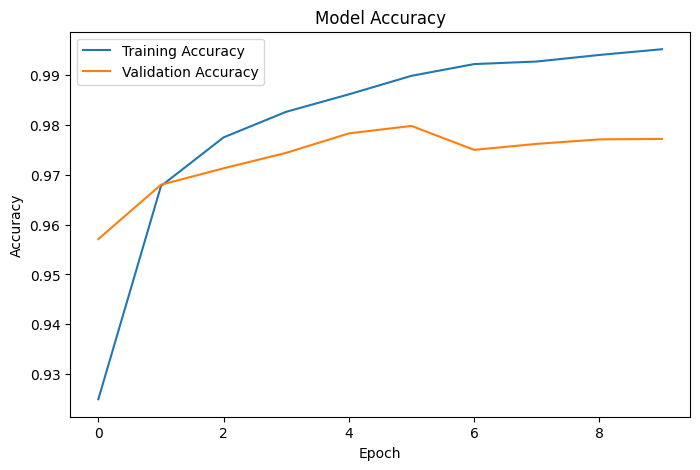

In [ ]:
# Plot Training & Validation Accuracy

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Observations

- Training accuracy increased consistently throughout the training process.
- Validation accuracy improved during the initial epochs and then stabilized around **97–98%**.
- The model achieved high accuracy on both the training and validation datasets.
- A small gap between the training and validation accuracy indicates good generalization.
- After approximately **5–6 epochs**, validation accuracy showed minimal improvement while training accuracy continued to increase.

Visualize the training and validation loss over all epochs to analyze the model's learning behavior.

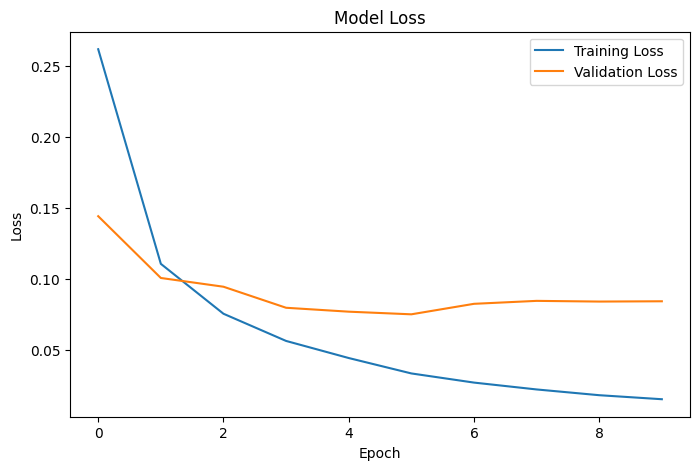

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Observations

- Training loss decreased consistently across all epochs, indicating continuous learning.
- Validation loss decreased during the initial epochs and reached its minimum around **Epoch 5**.
- After approximately **5–6 epochs**, validation loss increased slightly while training loss continued to decrease.
- This suggests the model began to slightly overfit the training data in the later epochs.
- Overall, the model achieved good performance with only minor signs of overfitting.

Evaluate the trained model on the test dataset to measure its final loss and accuracy on unseen data.

### Key Concepts

#### `model.evaluate()`
- Evaluates the trained model on unseen test data.
- Returns the values of the loss function and evaluation metrics specified during `compile()`.

#### `test_loss`
- Represents the prediction error of the model on the test dataset.
- Lower values indicate better performance.

#### `test_accuracy`
- Represents the percentage of correctly classified test samples.
- Measures how well the model generalizes to unseen data.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0844
Test Loss: 0.0843602791428566
Test Accuracy: 0.9771999716758728


### Observations

- The trained model was evaluated on the unseen test dataset.
- The test dataset was processed in **313 mini-batches**.
- The model achieved a **test accuracy of approximately 97.72%**, indicating good generalization.
- The final **test loss was approximately 0.0844**, showing a low prediction error on unseen data.
- `model.evaluate()` returned both the loss and accuracy values, which were stored in `test_loss` and `test_accuracy`.

Generate predictions for the test dataset using the trained model.

### Key Concepts

#### `model.predict()`
- Uses the trained model to generate predictions for the input data.
- Returns the predicted probability distribution for each class.
- Does not modify or retrain the model.

#### `x_test`
- Input test images on which predictions are made.
- Represents unseen data that was not used for training.

#### `predictions`
- Stores the predicted probabilities for all test samples.
- Each prediction contains probabilities for the 10 digit classes (0–9).

In [ ]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print(predictions.shape)

(10000, 10)


### Observations

- `model.predict()` generated predictions for all test images.
- The output shape is **(10000, 10)**.
- Each row represents one test image.
- Each column represents the predicted probability of one digit class (0–9).
- Predictions are returned as probability distributions, not class labels.

Inspect the predicted probability distribution for a single test image.

### Key Concepts

#### `predictions[0]`
- Returns the prediction for the first test image.
- Contains 10 probability values, one for each digit class (0–9).
- The probabilities sum to **1** because the output layer uses the **Softmax** activation function.

In [ ]:
print(predictions[0])

[2.4249659e-13 1.1789123e-12 2.1282098e-08 2.6516104e-04 3.6653572e-14
 5.2726318e-10 4.7783846e-18 9.9973488e-01 3.2174199e-10 7.5209305e-09]


Convert the predicted probability distribution into the final predicted class label.

### Key Concepts

#### `np.argmax()`
- Returns the index of the maximum value in an array.
- Since each index represents a digit (0–9), the returned index is the predicted class.

#### `predictions[0]`
- Contains the probability distribution for the first test image.

#### `predicted_label`
- Stores the digit with the highest predicted probability.

In [ ]:
predicted_label = np.argmax(predictions[0])
print("Predicted Label:", predicted_label)

Predicted Label: 7


Compare the predicted class label with the actual class label of the test image.

### Key Concepts

#### `np.argmax(predictions[0])`
- Returns the predicted class by selecting the index with the highest probability.

#### `y_test[0]`
- Returns the actual (ground truth) label of the first test image.

#### Prediction Comparison
- Comparing the predicted and actual labels helps verify whether the model classified the image correctly.

In [ ]:
print("Predicted Label:", np.argmax(predictions[0]))
print("Actual Label:", y_test[0])

Predicted Label: 7
Actual Label: 7


### Observations

- `np.argmax()` selected the class with the highest predicted probability.
- The predicted label matched the actual label for the first test image.
- The model successfully classified the first handwritten digit.
- The predicted probabilities were converted into a class label using `np.argmax()`.

Display the test image along with its predicted and actual labels to visually verify the model's prediction.

### Key Concepts

##### `plt.imshow()`
- Displays the selected test image.

##### `cmap='gray'`
- Displays the image in grayscale.

##### `plt.title()`
- Adds the predicted and actual labels as the image title.

##### `plt.axis('off')`
- Removes the x-axis and y-axis for a cleaner visualization.

##### `plt.show()`
- Displays the final output image.

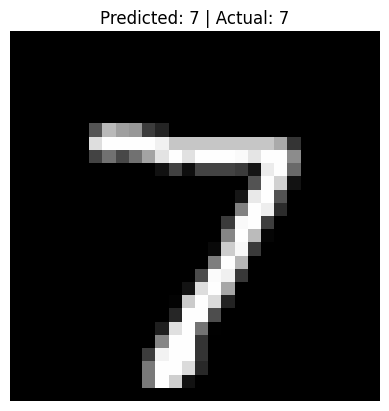

In [ ]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])} | Actual: {y_test[0]}")
plt.axis('off')
plt.show()

### Observations

- The handwritten digit was displayed successfully.
- The predicted label and actual label matched, confirming a correct prediction.
- Visualizing predictions helps verify the model's performance beyond numerical metrics.

### Conclusion

- Successfully built and trained a Multi-Layer Perceptron (MLP) using TensorFlow and Keras.
- Achieved approximately **97.7%** accuracy on the MNIST test dataset.
- Learned the complete deep learning workflow, including data preprocessing, model creation, training, evaluation, and prediction.
- Visualized training performance using accuracy and loss curves, and verified predictions on unseen handwritten digit images.